<a href="https://colab.research.google.com/github/nanopiano/AUTH_IDS/blob/main/auth_ids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install SHAP

In [ ]:
!pip install shap -q

# Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score, recall_score, f1_score, roc_auc_score
)

def evaluate_binary_model(y_true, y_pred, y_score=None, model_name="Model", scope="Full test set"):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results = {
        "Model": model_name,
        "Evaluation Scope": scope, # Added for LSTM evaluation clarity
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0,
        "FNR": fn / (fn + tp) if (fn + tp) > 0 else 0,
    }

    if y_score is not None:
        results["AUC"] = roc_auc_score(y_true, y_score)
    else:
        results["AUC"] = np.nan # Use NaN if AUC is not applicable or provided

    return results


# Set Path and List Files

In [ ]:
base_path = "/content/drive/MyDrive/dataset"

print("Files found:")
for f in sorted(os.listdir(base_path)):
    print(f)

Files found:
ARP_Spoofing_test.pcap.csv
ARP_Spoofing_train.pcap.csv
Benign_test.pcap.csv
Benign_train.pcap.csv
MQTT-DDoS-Connect_Flood_test.pcap.csv
MQTT-DDoS-Connect_Flood_train.pcap.csv
MQTT-DoS-Connect_Flood_test.pcap.csv
MQTT-DoS-Connect_Flood_train.pcap.csv
Recon-OS_Scan_test.pcap.csv
Recon-OS_Scan_train.pcap.csv
Recon-Port_Scan_test.pcap.csv
Recon-Port_Scan_train.pcap.csv
Recon-VulScan_test.pcap.csv
Recon-VulScan_train.pcap.csv
TCP_IP-DDoS-SYN1_train.pcap.csv
TCP_IP-DDoS-SYN_test.pcap.csv
TCP_IP-DoS-SYN1_train.pcap.csv
TCP_IP-DoS-SYN_test.pcap.csv


# Define Files & Check Existence

The training and testing file lists are defined, and their existence in the specified `base_path` is verified to ensure all necessary data is available for processing.

In [ ]:
train_files = [
    "Benign_train.pcap.csv", "ARP_Spoofing_train.pcap.csv", "MQTT-DDoS-Connect_Flood_train.pcap.csv",
    "MQTT-DoS-Connect_Flood_train.pcap.csv", "Recon-Port_Scan_train.pcap.csv", "Recon-OS_Scan_train.pcap.csv",
    "Recon-VulScan_train.pcap.csv", "TCP_IP-DDoS-SYN1_train.pcap.csv", "TCP_IP-DoS-SYN1_train.pcap.csv"
]

test_files = [
    "Benign_test.pcap.csv", "ARP_Spoofing_test.pcap.csv", "MQTT-DDoS-Connect_Flood_test.pcap.csv",
    "MQTT-DoS-Connect_Flood_test.pcap.csv", "Recon-Port_Scan_test.pcap.csv", "Recon-OS_Scan_test.pcap.csv",
    "Recon-VulScan_test.pcap.csv", "TCP_IP-DDoS-SYN_test.pcap.csv", "TCP_IP-DoS-SYN_test.pcap.csv"
]

missing_train = [f for f in train_files if not os.path.exists(os.path.join(base_path, f))]
missing_test = [f for f in test_files if not os.path.exists(os.path.join(base_path, f))]

print("Missing train files:", missing_train)
print("Missing test files:", missing_test)

Missing train files: []
Missing test files: []


# Label Mapping

In [ ]:
label_map = {
    "Benign": "benign", "ARP_Spoofing": "spoofing",
    "MQTT-DDoS-Connect_Flood": "mqtt_auth_attack", "MQTT-DoS-Connect_Flood": "mqtt_auth_attack",
    "Recon-Port_Scan": "recon", "Recon-OS_Scan": "recon", "Recon-VulScan": "recon",
    "TCP_IP-DDoS-SYN": "syn_attack", "TCP_IP-DDoS-SYN1": "syn_attack",
    "TCP_IP-DoS-SYN": "syn_attack", "TCP_IP-DoS-SYN1": "syn_attack",
}

def get_label(filename):
    name = filename.replace("_train.pcap.csv", "").replace("_test.pcap.csv", "")
    return label_map[name]

# Load and Merge

In [ ]:
train_dfs = []
for file in train_files:
    df = pd.read_csv(os.path.join(base_path, file))
    df["label"] = get_label(file)
    df["source_file"] = file
    train_dfs.append(df)

test_dfs = []
for file in test_files:
    df = pd.read_csv(os.path.join(base_path, file))
    df["label"] = get_label(file)
    df["source_file"] = file
    test_dfs.append(df)

train_df = pd.concat(train_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

print(f"Original train_df shape: {train_df.shape}")
print(f"Original test_df shape: {test_df.shape}")

display(train_df["label"].value_counts())

Original train_df shape: (808395, 47)
Original test_df shape: (382880, 47)


,count
label,
syn_attack,310821
benign,192732
mqtt_auth_attack,185809
recon,102986
spoofing,16047


# Filtering Authentication-Relevant Labels

 we filter the dataset to include only 'benign' traffic and specific attack types. This ensures our models are trained and evaluated on data pertinent to the defined threat model, where reconnaissance and SYN attacks are considered relevant due to their impact on authentication processes.

In [ ]:
auth_attack_labels = [
    "benign",
    "mqtt_auth_attack",
    "spoofing",
    "recon",
    "syn_attack"
]

train_df = train_df[train_df["label"].isin(auth_attack_labels)].copy()
test_df = test_df[test_df["label"].isin(auth_attack_labels)].copy()

print(f"Filtered train_df shape: {train_df.shape}")
print(f"Filtered test_df shape: {test_df.shape}")

display(train_df["label"].value_counts())

Filtered train_df shape: (808395, 47)
Filtered test_df shape: (382880, 47)


,count
label,
syn_attack,310821
benign,192732
mqtt_auth_attack,185809
recon,102986
spoofing,16047


# Distribution Visuals & Column Alignment

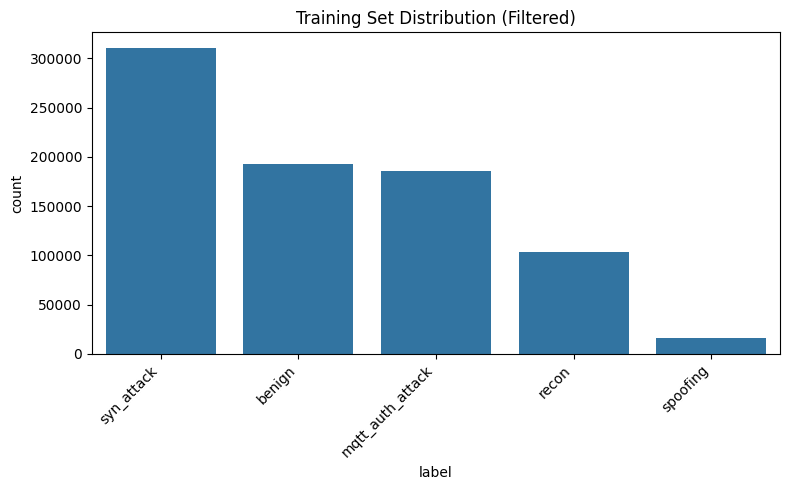

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=train_df, x="label", order=train_df["label"].value_counts().index)
plt.title("Training Set Distribution (Filtered)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

common_cols = sorted(list(set(train_df.columns).intersection(set(test_df.columns))))
train_df = train_df[common_cols]
test_df = test_df[common_cols]

# Processing and Scaling

In [ ]:
drop_cols = ["label", "source_file"]
X_train = train_df.drop(columns=drop_cols, errors="ignore").apply(pd.to_numeric, errors="coerce").fillna(0)
X_test = test_df.drop(columns=drop_cols, errors="ignore").apply(pd.to_numeric, errors="coerce").fillna(0)

# Re-initialize LabelEncoder and StandardScaler for filtered data
le = LabelEncoder()
y_train_enc = le.fit_transform(train_df["label"])
y_test_enc = le.transform(test_df["label"])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Are columns identical? {list(X_train.columns) == list(X_test.columns)}")
print(f"\nSample of features used:\n{X_train.columns[:10].tolist()}")

# Check for any potential leakage (like source_file or labels staying in X)
leakage_check = [col for col in X_train.columns if 'label' in col.lower() or 'file' in col.lower()]
print(f"Potential leakage columns found in features: {leakage_check}")

# Verify target distribution balance
print("\nEncoded Label Mapping:")
for i, item in enumerate(le.classes_):
    print(f"{i}: {item}")

Train shape: (808395, 45), Test shape: (382880, 45)
Are columns identical? True

Sample of features used:
['ARP', 'AVG', 'Covariance', 'DHCP', 'DNS', 'Drate', 'Duration', 'HTTP', 'HTTPS', 'Header_Length']
Potential leakage columns found in features: []

Encoded Label Mapping:
0: benign
1: mqtt_auth_attack
2: recon
3: spoofing
4: syn_attack


#  Train Ensemble & Predict

In [ ]:
# Initialize and train individual base models
# RandomForestClassifier: A robust ensemble method using multiple decision trees.
# AdaBoostClassifier: An adaptive boosting ensemble method.
# BaggingClassifier: Another ensemble method that trains base estimators on random subsets of the original dataset.
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train_scaled, y_train_enc)
ada = AdaBoostClassifier(n_estimators=100, random_state=42).fit(X_train_scaled, y_train_enc)
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42, n_jobs=-1).fit(X_train_scaled, y_train_enc)

# Get predictions from each model on the test set
rf_preds = rf.predict(X_test_scaled)
ada_preds = ada.predict(X_test_scaled)
bag_preds = bag.predict(X_test_scaled)

# Stack predictions vertically to form a matrix where each row corresponds to a sample
# and each column corresponds to a model's prediction for that sample.
preds = np.vstack([rf_preds, ada_preds, bag_preds]).T

# Combine predictions using a majority voting scheme.
# If there's a tie (e.g., two models predict class A, one predicts class B), it defaults to the AdaBoost prediction (row[1]).
# This creates the final ensemble prediction for each sample.
final_pred = np.array([np.unique(row, return_counts=True)[0][np.argmax(np.unique(row, return_counts=True)[1])] if len(np.unique(row, return_counts=True)[0]) < 3 else row[1] for row in preds])

# Advanced Model (G-KDE)
The G-KDE (Gaussian Kernel Density Estimation) model is an advanced component for anomaly detection. It is trained on benign records to establish a baseline of normality.

In [ ]:
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import train_test_split

# --- KDE feature selection fix: Use top features by Random Forest importance ---
# Calculate feature importances from the already trained Random Forest model (rf)
feature_importances = rf.feature_importances_

# Get the names of features in X_train
feature_names = X_train.columns

# Create a Series for easier sorting
importance_series = pd.Series(feature_importances, index=feature_names)

# Sort features by importance and select the top N (e.g., top 10 as used previously)
kde_feature_count = 10
selected_kde_features = importance_series.nlargest(kde_feature_count).index.tolist()

print(f"Selected {kde_feature_count} features for G-KDE based on RF importance: {selected_kde_features}")

# Filter X_train_scaled and X_test_scaled to include only selected features
X_train_kde = X_train_scaled[:, [feature_names.get_loc(col) for col in selected_kde_features]]
X_test_kde = X_test_scaled[:, [feature_names.get_loc(col) for col in selected_kde_features]]

# --- KDE threshold leakage fix: Create threshold from benign training data only ---
# 1. Filter for benign samples from the training set
benign_mask_train = train_df["label"] == "benign"
X_benign_train_full = X_train_kde[benign_mask_train.values]

# 2. Split benign training data into KDE-train and KDE-validation
# This ensures the threshold is learned from training data only, without touching the test set.
# We use a small validation set (e.g., 20%) to determine the threshold.
if len(X_benign_train_full) > 0:
    X_kde_fit, X_kde_threshold_val = train_test_split(
        X_benign_train_full, test_size=0.2, random_state=42
    )
else:
    print("Warning: No benign samples in training data for KDE.")
    X_kde_fit = X_benign_train_full
    X_kde_threshold_val = X_benign_train_full

# Sample to make runtime practical for fitting KDE on KDE-train subset
max_kde_samples = 20000
if len(X_kde_fit) > max_kde_samples:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_kde_fit), size=max_kde_samples, replace=False)
    X_kde_fit = X_kde_fit[idx]

# Fit KDE on the KDE-train subset
kde = KernelDensity(kernel="gaussian", bandwidth=1.0)
kde.fit(X_kde_fit)

# Score the KDE-validation subset to determine the threshold
if len(X_kde_threshold_val) > 0:
    benign_threshold_scores = kde.score_samples(X_kde_threshold_val)
    # Choose threshold (e.g., 5th percentile of benign scores) from the validation set
    threshold = np.percentile(benign_threshold_scores, 5)
else:
    print("Warning: No benign samples in KDE threshold validation set. Setting threshold to a default value.")
    threshold = -100 # A very low default threshold if no benign data to learn from

# Score the actual test set using the learned KDE model
kde_scores = kde.score_samples(X_test_kde)

# Binary prediction on the test set based on the learned threshold
kde_pred_binary = (kde_scores < threshold).astype(int)

# For evaluation, prepare y_test_binary_kde (unchanged, still attack vs. benign)
benign_mask_test = test_df["label"] == "benign"
y_test_binary_kde = np.where(benign_mask_test, 0, 1) # 0 for benign, 1 for attack

# Display KDE metrics with updated scope parameter
kde_results = evaluate_binary_model(y_test_binary_kde, kde_pred_binary, model_name="G-KDE Only", scope="Full test set")
print(f"G-KDE FPR: {kde_results['FPR']:.4f}, FNR: {kde_results['FNR']:.4f}")


Selected 10 features for G-KDE based on RF importance: ['fin_count', 'AVG', 'Magnitue', 'rst_count', 'Tot size', 'fin_flag_number', 'ack_count', 'syn_flag_number', 'syn_count', 'Header_Length']
G-KDE FPR: 0.0811, FNR: 0.7135


# **Advanced Model (LSTM)**
The LSTM (Long Short-Term Memory) model is an advanced component for temporal sequence analysis, focusing on the MQTT subset.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
# Accessing layers directly from tf.keras to resolve import path warnings
layers = tf.keras.layers

# Filter MQTT subset from train and test
mqtt_mask_train = train_df["label"].isin(["mqtt_auth_attack", "benign"])
mqtt_mask_test = test_df["label"].isin(["mqtt_auth_attack", "benign"])

X_mqtt_train = X_train_scaled[mqtt_mask_train.values]
y_mqtt_train = np.where(train_df["label"][mqtt_mask_train].values == "benign", 0, 1)

X_mqtt_test = X_test_scaled[mqtt_mask_test.values]
y_mqtt_test = np.where(test_df["label"][mqtt_mask_test].values == "benign", 0, 1)

# --- LSTM sequence construction improvement: Add warning comment ---
# Warning: Sequence order depends on the current dataset ordering.
# Without explicit time-related or flow-related columns to sort by, these sequences
# may not reflect true session chronology, which could impact model performance.
# The current approach assumes that adjacent rows (after filtering for MQTT subset)
# have some temporal or logical relationship.

# Create sliding windows of size 10
def create_sequences(X, y, window=10):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_seq_train, y_seq_train = create_sequences(X_mqtt_train, y_mqtt_train)
X_seq_test, y_seq_test = create_sequences(X_mqtt_test, y_mqtt_test)

# Build LSTM using the updated layers reference
model = Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(10, X_seq_train.shape[2])),
    layers.Dropout(0.2),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
es = EarlyStopping(patience=5, restore_best_weights=True)
model.fit(X_seq_train, y_seq_train, epochs=20, batch_size=64,
          validation_split=0.1, callbacks=[es], verbose=1)

# Evaluate LSTM on the subset it was trained for
lstm_pred_prob_subset = model.predict(X_seq_test).flatten()
lstm_pred_binary_subset = (lstm_pred_prob_subset > 0.5).astype(int)

tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_seq_test, lstm_pred_binary_subset).ravel()
print(f"LSTM FPR (subset): {fp_l/(fp_l+tn_l):.4f}, FNR (subset): {fn_l/(fn_l+tp_l):.4f}")

# Create a full-length prediction array for LSTM for fusion
lstm_pred_binary = np.zeros(len(test_df), dtype=int) # Initialize all as benign (0)

# Get the original indices from test_df that correspond to the samples predicted by LSTM
# These are the indices where mqtt_mask_test is True, and then shifted by the window size
# because create_sequences takes X[i+window] as the label for sequence i.
original_test_indices_for_lstm = test_df.index[mqtt_mask_test][10:] # window is 10

# Assign the LSTM predictions to their corresponding positions in the full array
lstm_pred_binary[original_test_indices_for_lstm] = lstm_pred_binary_subset


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
5324/5324 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 4.3642e-06
Epoch 2/20
5324/5324 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 1.0000 - loss: 7.4143e-05 - val_accuracy: 1.0000 - val_loss: 1.6352e-07
Epoch 3/20
5324/5324 ━━━━━━━━━━━━━━━━━━━━ 81s 8ms/step - accuracy: 1.0000 - loss: 3.9284e-05 - val_accuracy: 1.0000 - val_loss: 1.7161e-08
Epoch 4/20
5324/5324 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 1.0000 - loss: 9.2458e-05 - val_accuracy: 1.0000 - val_loss: 7.3192e-08
Epoch 5/20
5324/5324 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 1.0000 - loss: 3.7700e-05 - val_accuracy: 1.0000 - val_loss: 8.8747e-08
Epoch 6/20
5324/5324 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - accuracy: 1.0000 - loss: 3.2617e-05 - val_accuracy: 1.0000 - val_loss: 6.5495e-09
Epoch 7/20
5324/5324 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - accuracy: 1.0000 - loss: 3.8055e-05 - val_accuracy: 1.0000 - val_loss: 3.3329e-09
Epoch 8/20
5324/5324 ━━━━━━━━━━

#  Generate Binary Predictions

This step converts the multi-class predictions from the ensemble model into binary (attack vs. benign) to align with the G-KDE and LSTM models for subsequent fusion and binary evaluation.

In [ ]:
# Convert ensemble multi-class predictions to binary (0 for benign, 1 for attack)
# First, identify the index of 'benign' in the LabelEncoder classes
benign_class_idx = np.where(le.classes_ == 'benign')[0][0]

# Then, convert the ensemble's final_pred to binary
# If final_pred == benign_class_idx, then 0 (benign), else 1 (attack)
ensemble_pred_binary = (final_pred != benign_class_idx).astype(int)

print(f"Ensemble binary predictions generated. Sample: {ensemble_pred_binary[:10]}")

Ensemble binary predictions generated. Sample: [0 0 0 0 0 0 0 0 0 0]


# Apply OR-logic Fusion

This step combines the binary predictions from the Ensemble, G-KDE, and LSTM models using an OR-logic. A sample is classified as an 'attack' if any of the three models predict it as an attack. This strategy aims to minimize False Negatives, which is crucial in intrusion detection systems.

In [ ]:
final_fused_pred_binary = (
    (ensemble_pred_binary == 1) |
    (kde_pred_binary == 1) |
    (lstm_pred_binary == 1)
).astype(int)

print(f"Fused binary predictions generated. Sample: {final_fused_pred_binary[:10]}")

Fused binary predictions generated. Sample: [0 0 0 0 0 0 0 0 0 0]


# Evaluate All Models

This section provides an evaluation of the individual ensemble, G-KDE, and LSTM models, as well as the final OR-logic fused model. All evaluations use the `evaluate_binary_model` function to ensure consistency in metrics for attack (1) vs. benign (0) classification. The `y_test_binary_kde` is used for G-KDE evaluation, `y_seq_test` for LSTM, and `y_test_binary` (derived from `y_test_enc`) for ensemble and fused models.

In [ ]:
# Prepare y_test_binary for ensemble and fused models
benign_class_idx = np.where(le.classes_ == 'benign')[0][0]
y_test_binary = (y_test_enc != benign_class_idx).astype(int)

# For ROC, we need probability scores. LSTM provides probabilities (lstm_pred_prob).
# For Ensemble, we can get probabilities from the base RF model (or average of base models).
# For KDE, kde_scores are log-likelihoods; lower scores indicate higher likelihood of attack.

# --- Ensemble (RandomForest) AUC calculation ---
rf_proba = rf.predict_proba(X_test_scaled)
ensemble_attack_proba = 1 - rf_proba[:, benign_class_idx] # Probability of attack = 1 - probability of benign
auc_ensemble = roc_auc_score(y_test_binary, ensemble_attack_proba)

# --- G-KDE AUC calculation ---
# For KDE, lower score_samples means higher anomaly likelihood. So, use -kde_scores as prediction scores.
auc_kde = roc_auc_score(y_test_binary_kde, -kde_scores)

# --- LSTM AUC calculation ---
auc_lstm = roc_auc_score(y_seq_test, lstm_pred_prob_subset)

# Evaluate Ensemble model with explicit scope and AUC
ensemble_eval = evaluate_binary_model(y_test_binary, ensemble_pred_binary, y_score=ensemble_attack_proba, model_name="Ensemble", scope="Full test set")

# Evaluate G-KDE model (y_test_binary_kde was prepared in KDE cell) with explicit scope and AUC
kde_eval = evaluate_binary_model(y_test_binary_kde, kde_pred_binary, y_score=-kde_scores, model_name="G-KDE", scope="Full test set")

# Evaluate LSTM model (y_seq_test from LSTM cell) with explicit scope and AUC
lstm_eval = evaluate_binary_model(y_seq_test, lstm_pred_binary_subset, y_score=lstm_pred_prob_subset, model_name="LSTM", scope="MQTT subset only")

# Evaluate Fused model (OR-Logic) - AUC is not directly applicable for binary OR-fusion
fused_eval = evaluate_binary_model(y_test_binary, final_fused_pred_binary, model_name="Fused (OR-Logic)", scope="Full test set", y_score=None) # AUC is NaN

# Collect all results into a DataFrame
metrics_df = pd.DataFrame([ensemble_eval, kde_eval, lstm_eval, fused_eval]).set_index("Model")

print("--- Model Performance Summary (Binary Classification) ---")
display(metrics_df)

# --- Fusion evaluation improvement: Add explicit interpretation ---
print("\n--- Fusion Strategy Interpretation ---")
print("OR-fusion was used to reduce false negatives by flagging a sample as attack if any detector raised an alert,")
print("at the cost of potentially increasing false positives. This prioritizes sensitivity in attack detection.")


--- Model Performance Summary (Binary Classification) ---


,Evaluation Scope,Accuracy,Precision,Recall,F1,FPR,FNR,AUC
Model,,,,,,,,
Ensemble,Full test set,0.996357,0.998654,0.997304,0.997978,0.012338,0.002696,0.999740
G-KDE,Full test set,0.348584,0.970095,0.286463,0.442314,0.081075,0.713537,0.894787
LSTM,MQTT subset only,0.999927,1.000000,0.999867,0.999933,0.000000,0.000133,0.999976
Fused (OR-Logic),Full test set,0.992374,0.993915,0.997651,0.995779,0.056080,0.002349,NaN



--- Fusion Strategy Interpretation ---
OR-fusion was used to reduce false negatives by flagging a sample as attack if any detector raised an alert,
at the cost of potentially increasing false positives. This prioritizes sensitivity in attack detection.


# Plot Confusion Matrix and ROC Curve

This section visualizes the performance of the final OR-logic fused model through a confusion matrix and a Receiver Operating Characteristic (ROC) curve, focusing on its ability to distinguish between benign and attack traffic.

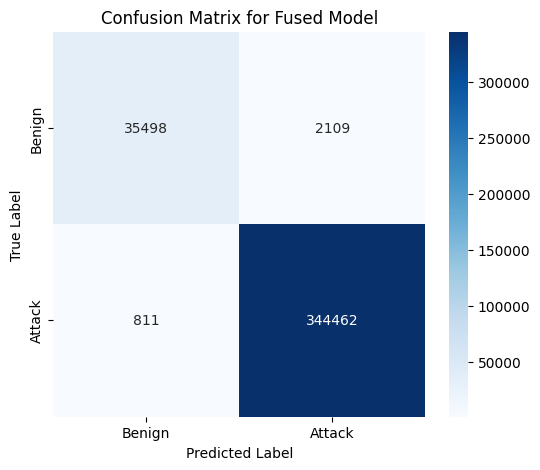

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Confusion Matrix for Fused Model
cm_fused = confusion_matrix(y_test_binary, final_fused_pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_fused, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.title("Confusion Matrix for Fused Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curves for Comparable Models

This section generates two separate ROC plots for better clarity and comparability:

1.  **Full Test Set Models**: Compares the Ensemble and G-KDE models, as both are evaluated on the entire test dataset.
2.  **MQTT Subset Model**: Plots the ROC curve specifically for the LSTM model, which is trained and evaluated only on the MQTT-related subset of the data.

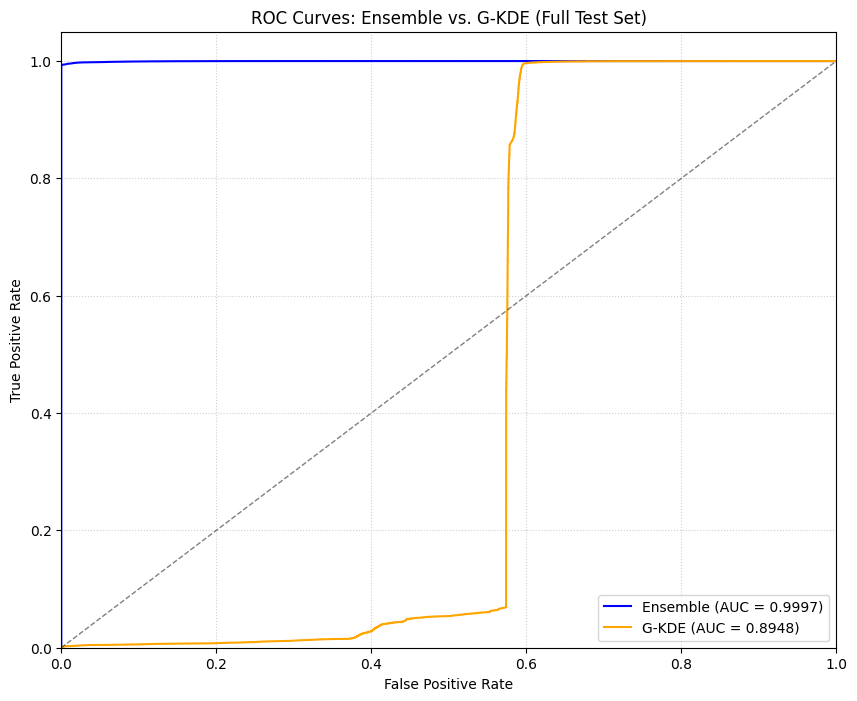

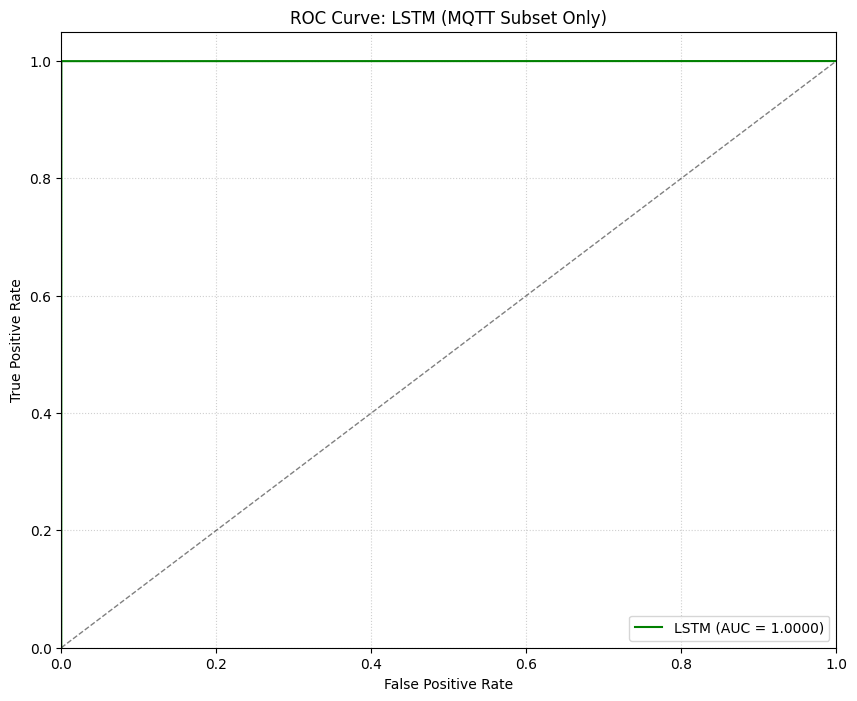

In [ ]:
# --- ROC plotting fix: Plot comparable models together ---

# 1. Plot for Full Test Set Models (Ensemble, G-KDE)
plt.figure(figsize=(10, 8))
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {auc_ensemble:.4f})', color='blue')
plt.plot(fpr_kde, tpr_kde, label=f'G-KDE (AUC = {auc_kde:.4f})', color='orange')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Ensemble vs. G-KDE (Full Test Set)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 2. Plot for MQTT Subset Model (LSTM)
plt.figure(figsize=(10, 8))
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.4f})', color='green')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: LSTM (MQTT Subset Only)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Interpretability (Importance & SHAP)


In [ ]:
import shap
import matplotlib.pyplot as plt

# Use 'rf' as the best_rf_model for SHAP
best_rf_model = rf
selected_feature_names = X_train.columns

# sample small background and explanation set
X_shap_bg = X_train_scaled[np.random.choice(len(X_train_scaled), 200, replace=False)]
X_shap_sample = X_test_scaled[np.random.choice(len(X_test_scaled), 300, replace=False)]

explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_shap_sample)

# Ensure shap_values is an array of arrays if it's a list for multi-class
if isinstance(shap_values, list):
    # For multi-class, shap_values is a list of arrays, one per class.
    # For a summary plot, typically you'd sum them or pick one class's values.
    # Let's sum the absolute SHAP values for overall feature importance.
    # Or, if we're focusing on 'attack' vs 'benign', we can pick the 'attack' class index.
    # Assuming 'benign' is class 0, and attack classes are > 0, let's use the first attack class (index 1) for demonstration
    if len(le.classes_) > 1: # If multi-class and not just binary, pick an attack class
        attack_class_idx = 1 # Assuming index 1 is an attack class, adjust if needed
        if attack_class_idx < len(shap_values):
            shap_values_to_plot = shap_values[attack_class_idx]
        else:
            shap_values_to_plot = shap_values[0] # Fallback to benign if only one class or index out of bound
    else:
        shap_values_to_plot = shap_values[0] # For binary, it might just be one array or a list with one item
else:
    shap_values_to_plot = shap_values

# --- SHAP improvement: Clarify that SHAP explains the RF component ---
# This SHAP summary plot explains the feature importance and impact specifically
# for the Random Forest classifier component of the ensemble, not the entire
# fused detection system. It shows how much each feature contributes to pushing
# the model's output from the base value to the final prediction for the target class.
shap.summary_plot(shap_values_to_plot, X_shap_sample, feature_names=selected_feature_names, show=False)
plt.tight_layout()
plt.savefig(os.path.join(base_path, "shap_summary.png"), dpi=300, bbox_inches="tight")
plt.close()
print(f"SHAP summary plot saved to {os.path.join(base_path, 'shap_summary.png')}")


SHAP summary plot saved to /content/drive/MyDrive/dataset/shap_summary.png
